# AQI Forecasting — XGBoost Model (Patia)
**Dataset:** `Patia_AQI_cleaned.csv`  
**Granularity:** Hourly (19,107 observations · Oct 2023 – Dec 2025)  
**Target:** AQI (continuous regression) → AQI_Category (classification evaluation)  
**Model:** XGBoost Gradient-Boosted Trees

> **EDA Findings applied here:**  
> • XGBoost prefers hourly data — more rows = better generalization (EDA §10.1)  
> • Key features: PM25, PM10, CO, NOx (r > 0.6 with AQI), O3 & WS negative  
> • Hourly lag features 1–24h + 48h (strong autocorrelation at short lags)  
> • Cyclic encoding for Hour, Month, DayOfWeek (dual rush-hour peak pattern)  
> • 70/15/15 chronological split — NO random splits (EDA §10.7)  
> • Stationarity not required for XGBoost (non-parametric, EDA §10.2)


## 0. Environment Setup

In [20]:
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score)
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

# ── Paths ──────────────────────────────────────────────────────
DATA_PATH   = r"D:\AQI_Project_new\data\clean\Patia_AQI_cleaned.csv"   # ← change only this line per city
MODEL_DIR   = 'saved_models'
IMAGE_DIR   = 'images'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

RANDOM_SEED = 42

print(f'XGBoost version : {xgb.__version__}')
print('✅ All imports successful.')


XGBoost version : 2.1.3
✅ All imports successful.


## 1. Load & Preprocess Data
EDA confirmed: 19,107 hourly rows, 0 missing values, all columns numeric except `Timestamp` and `AQI_Category`.  
We keep the **hourly** granularity as recommended in EDA §10.1 — daily aggregation is NOT used here.


In [21]:
# ── 1.1  Load raw hourly data ─────────────────────────────────
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')
print(f'Nulls      : {df.isnull().sum().sum()}')
print(f'Duplicates : {df.duplicated(subset=["Timestamp"]).sum()}')
df.head(3)


Shape      : (19107, 23)
Date range : 2023-10-27 21:00:00  →  2025-12-31 23:00:00
Nulls      : 0
Duplicates : 0


,Timestamp,NO,NOx,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,...,SR,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2023-10-27 21:00:00,4.03,16.34,3.29,13.34,0.93,1.16,25.73,64.88,0.5,...,41.04,304.08,241.59,30.71,53.06,4.71,42.12,81.36,81.36,Satisfactory
1,2023-10-27 22:00:00,4.03,16.34,3.29,13.34,0.93,1.16,25.73,64.88,0.5,...,41.04,304.08,241.59,30.71,53.06,4.71,38.84,82.07,82.07,Satisfactory
2,2023-10-27 23:00:00,4.03,16.34,3.29,13.34,0.93,1.16,25.73,64.88,0.5,...,41.04,304.08,241.59,30.71,53.06,4.71,36.12,79.83,79.83,Satisfactory


In [22]:
# ── 1.2  Encode AQI_Category (label-encode; keep raw string for plots) ──
cat_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_enc   = {c: i for i, c in enumerate(cat_order)}
df['AQI_Category_Enc'] = df['AQI_Category'].map(cat_enc)

# ── 1.3  Season & calendar columns (from EDA §4) ──────────────
df['Hour']       = df['Timestamp'].dt.hour
df['DayOfWeek']  = df['Timestamp'].dt.dayofweek
df['Month']      = df['Timestamp'].dt.month
df['Year']       = df['Timestamp'].dt.year
df['DayOfYear']  = df['Timestamp'].dt.dayofyear
df['Quarter']    = df['Timestamp'].dt.quarter
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',
              9:'Autumn',10:'Autumn',11:'Autumn'}
df['Season']     = df['Month'].map(season_map)
season_enc_map   = {'Winter':0,'Spring':1,'Summer':2,'Autumn':3}
df['Season_Enc'] = df['Season'].map(season_enc_map)

print('Calendar features added.')
print(df[['Timestamp','Hour','DayOfWeek','Month','Season','IsWeekend']].head(3))


Calendar features added.
            Timestamp  Hour  DayOfWeek  Month  Season  IsWeekend
0 2023-10-27 21:00:00    21          4     10  Autumn          0
1 2023-10-27 22:00:00    22          4     10  Autumn          0
2 2023-10-27 23:00:00    23          4     10  Autumn          0


## 2. Feature Engineering
Based on EDA §9.2 and §10.4:  
- **Hourly lag features** (1–24h, 48h) — strong autocorrelation at all hourly lags  
- **Rolling statistics** — 3h, 6h, 24h rolling mean & std  
- **Cyclic encoding** — Hour, Month, DayOfWeek encoded as sin/cos to capture periodicity  
- **All pollutants + weather columns** — PM25, PM10, CO, NOx etc. included as raw features  
- No stationarity transformation needed (XGBoost is non-parametric)


In [23]:
# ── 2.1  Define pollutant & weather feature groups (from EDA §2.3) ──
_pollutant_candidates = ['NO','NOx','Benzene','Toluene','Eth-Benzene','MP-Xylene',
                          'PM25','PM10','NO2','SO2','NH3','CO','O3']
_weather_candidates   = ['AT','RH','WS','WD','RF','TOT-RF','SR','BP']

pollutant_cols = [c for c in _pollutant_candidates if c in df.columns]
weather_cols   = [c for c in _weather_candidates   if c in df.columns]
print('Pollutant features :', pollutant_cols)
print('Weather features   :', weather_cols)


Pollutant features : ['NO', 'NOx', 'Benzene', 'Toluene', 'Eth-Benzene', 'MP-Xylene', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']
Weather features   : ['AT', 'RH', 'WS', 'WD', 'RF', 'TOT-RF', 'SR']


In [24]:
# ── 2.2  Build feature matrix ─────────────────────────────────
def create_features(df_in):
    df_f = df_in.copy()

    # ── Hourly lag features (AQI autocorrelation — EDA §9.2) ──
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        df_f[f'AQI_lag_{lag}h'] = df_f['AQI'].shift(lag)

    # ── Rolling statistics (shift-1 to prevent leakage) ────────
    for win in [3, 6, 24]:
        df_f[f'AQI_roll_mean_{win}h'] = df_f['AQI'].shift(1).rolling(win).mean()
        df_f[f'AQI_roll_std_{win}h']  = df_f['AQI'].shift(1).rolling(win).std()

    # ── Cyclic time encoding (EDA §10.4 — captures rush-hour pattern) ──
    df_f['Hour_sin']   = np.sin(2 * np.pi * df_f['Hour'] / 24)
    df_f['Hour_cos']   = np.cos(2 * np.pi * df_f['Hour'] / 24)
    df_f['Month_sin']  = np.sin(2 * np.pi * df_f['Month'] / 12)
    df_f['Month_cos']  = np.cos(2 * np.pi * df_f['Month'] / 12)
    df_f['DOW_sin']    = np.sin(2 * np.pi * df_f['DayOfWeek'] / 7)
    df_f['DOW_cos']    = np.cos(2 * np.pi * df_f['DayOfWeek'] / 7)

    return df_f


featured = create_features(df)
featured = featured.dropna()   # remove rows with NaN from lag creation

# ── Feature column list (exclude target & raw categoricals) ───
EXCLUDE = {'AQI', 'AQI_Category', 'Season', 'Timestamp'}
feature_cols = [c for c in featured.columns if c not in EXCLUDE]

print(f'Total features : {len(feature_cols)}')
print('Features:')
for f in feature_cols:
    print(f'  • {f}')


Total features : 48
Features:
  • NO
  • NOx
  • Benzene
  • Toluene
  • Eth-Benzene
  • MP-Xylene
  • AT
  • RH
  • WS
  • WD
  • RF
  • TOT-RF
  • SR
  • PM25
  • PM10
  • NO2
  • SO2
  • NH3
  • CO
  • O3
  • AQI_Category_Enc
  • Hour
  • DayOfWeek
  • Month
  • Year
  • DayOfYear
  • Quarter
  • IsWeekend
  • Season_Enc
  • AQI_lag_1h
  • AQI_lag_2h
  • AQI_lag_3h
  • AQI_lag_6h
  • AQI_lag_12h
  • AQI_lag_24h
  • AQI_lag_48h
  • AQI_roll_mean_3h
  • AQI_roll_std_3h
  • AQI_roll_mean_6h
  • AQI_roll_std_6h
  • AQI_roll_mean_24h
  • AQI_roll_std_24h
  • Hour_sin
  • Hour_cos
  • Month_sin
  • Month_cos
  • DOW_sin
  • DOW_cos


## 3. Train / Validation / Test Split (Chronological)
Per EDA §10.7: **70 / 15 / 15 time-based split** — NO random shuffling.  
Approximate boundaries for this dataset (Oct 2023 – Dec 2025):  
- Train : Oct 2023 → early May 2025 (70%)  
- Val   : May 2025 → early Sep 2025 (15%)  
- Test  : Sep 2025 → Dec 2025 (15%)


In [25]:
# ── 3.1  Chronological 70/15/15 split ────────────────────────
n = len(featured)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = featured.iloc[:train_end]
val   = featured.iloc[train_end:val_end]
test  = featured.iloc[val_end:]

X_train = train[feature_cols];  y_train = train['AQI']
X_val   = val[feature_cols];    y_val   = val['AQI']
X_test  = test[feature_cols];   y_test  = test['AQI']

print(f'Train : {len(train):,} rows  '
      f'({train["Timestamp"].min().date()} → {train["Timestamp"].max().date()})')
print(f'Val   : {len(val):,} rows  '
      f'({val["Timestamp"].min().date()}  → {val["Timestamp"].max().date()})')
print(f'Test  : {len(test):,} rows  '
      f'({test["Timestamp"].min().date()} → {test["Timestamp"].max().date()})')


Train : 13,341 rows  (2023-10-29 → 2025-05-07)
Val   : 2,859 rows  (2025-05-07  → 2025-09-03)
Test  : 2,859 rows  (2025-09-03 → 2025-12-31)


## 4. Train XGBoost Model
Using the validation split for early stopping.  
Hyperparameters tuned for hourly AQI — strong regularisation to avoid overfitting on the dense lag features.


In [26]:
model = xgb.XGBRegressor(
    n_estimators        = 1000,
    max_depth           = 6,
    learning_rate       = 0.02,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    min_child_weight    = 5,
    random_state        = RANDOM_SEED,
    n_jobs              = -1,
    early_stopping_rounds = 30,
    eval_metric         = 'rmse'
)

model.fit(
    X_train, y_train,
    eval_set    = [(X_val, y_val)],
    verbose     = 100
)

print(f'\nBest iteration : {model.best_iteration}')
print(f'Best val RMSE  : {model.best_score:.4f}')


[0]	validation_0-rmse:61.91475
[100]	validation_0-rmse:9.07422
[200]	validation_0-rmse:3.48743
[300]	validation_0-rmse:3.26477
[400]	validation_0-rmse:3.19513
[500]	validation_0-rmse:3.16290
[517]	validation_0-rmse:3.15438

Best iteration : 487
Best val RMSE  : 3.1527


## 5. Forecast & Evaluation

**Direct forecast** — uses actual test-period lag values (upper bound on performance).  
**Recursive forecast** — uses predicted values as lag inputs (realistic multi-step ahead).


In [27]:
# ── 5.1  Direct forecast ─────────────────────────────────────
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_direct[mask]) / y_test.values[mask])) * 100

print('XGBoost — Direct Forecast (Test Set)')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


XGBoost — Direct Forecast (Test Set)
  RMSE : 3.03
  MAE  : 1.59
  MAPE : 1.85%


In [28]:
# ── 5.2  Recursive (multi-step ahead) forecast ───────────────
def recursive_forecast(model, train_df, test_df, feature_cols):
    """Replaces AQI lag columns with predicted values step-by-step."""
    lag_cols = [c for c in feature_cols if c.startswith('AQI_lag_')]
    all_data  = pd.concat([train_df, test_df]).copy().reset_index(drop=True)
    n_train   = len(train_df)
    predictions = []

    for i in range(n_train, len(all_data)):
        feat = all_data.iloc[i][feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)

        if i + 1 < len(all_data):
            for lag_col in lag_cols:
                # e.g. 'AQI_lag_1h' → lag_n = 1
                lag_n = int(lag_col.split('_')[2].replace('h', ''))
                if len(predictions) >= lag_n:
                    all_data.at[i + 1, lag_col] = predictions[-lag_n]

    return np.array(predictions)


lag_feature_cols = [c for c in feature_cols if c.startswith('AQI_lag_')]
print(f'Lag features used in recursive forecast: {lag_feature_cols}')

pred_recursive = recursive_forecast(model, train, test, feature_cols)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
mask_r = y_test.values != 0
mape_r = np.mean(np.abs((y_test.values[mask_r] - pred_recursive[mask_r]) / y_test.values[mask_r])) * 100

print(f'\nXGBoost — Recursive Forecast (Test Set)')
print(f'  RMSE : {rmse_r:.2f}')
print(f'  MAE  : {mae_r:.2f}')
print(f'  MAPE : {mape_r:.2f}%')


Lag features used in recursive forecast: ['AQI_lag_1h', 'AQI_lag_2h', 'AQI_lag_3h', 'AQI_lag_6h', 'AQI_lag_12h', 'AQI_lag_24h', 'AQI_lag_48h']

XGBoost — Recursive Forecast (Test Set)
  RMSE : 3.88
  MAE  : 2.31
  MAPE : 2.84%


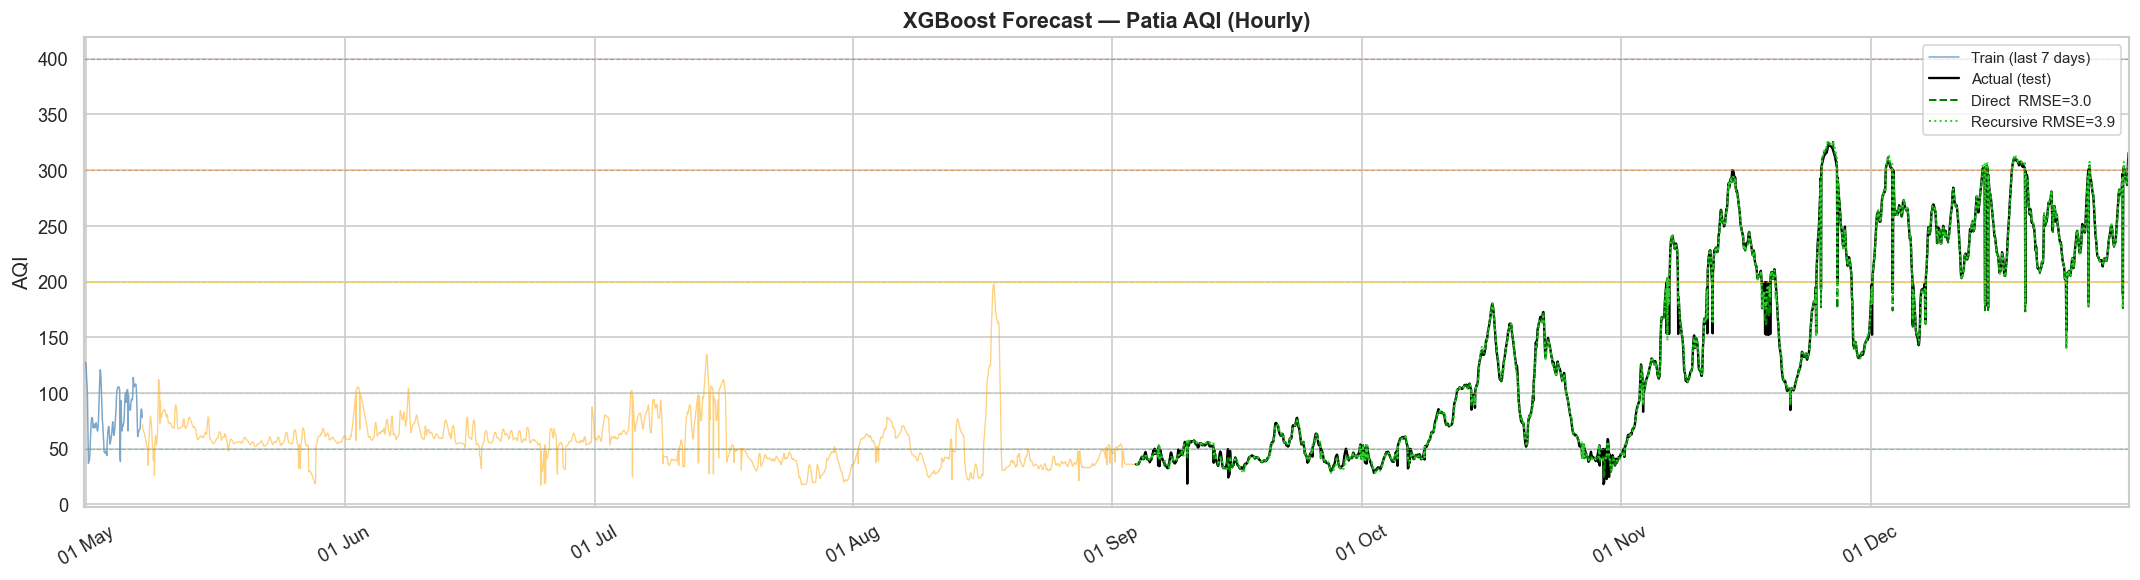

In [29]:
# ── 5.3  Forecast plot ────────────────────────────────────────
lookback_hours = 7 * 24
train_tail = train.tail(lookback_hours)

fig, ax = plt.subplots(figsize=(18, 5))

# Last 7 days of train
ax.plot(train_tail['Timestamp'], y_train.tail(lookback_hours),
        color='steelblue', lw=0.9, alpha=0.7, label='Train (last 7 days)')

# ── ADD: validation period fills the gap ──
ax.plot(val['Timestamp'], y_val,
        color='orange', lw=0.8, alpha=0.5, label='_nolegend_')

# Actual test
ax.plot(test['Timestamp'], y_test,
        color='black', lw=1.4, label='Actual (test)')

# Direct & recursive forecasts
ax.plot(test['Timestamp'], pred_direct,
        color='green', linestyle='--', lw=1.2, label=f'Direct  RMSE={rmse:.1f}')
ax.plot(test['Timestamp'], pred_recursive,
        color='limegreen', linestyle=':', lw=1.2, label=f'Recursive RMSE={rmse_r:.1f}')

# ── Set xlim so no blank stretch is shown ──
ax.set_xlim(train_tail['Timestamp'].iloc[0], test['Timestamp'].iloc[-1])

# Category threshold lines
thresholds = {'Good':50,'Satisfactory':100,'Moderate':200,'Poor':300,'Very Poor':400}
colors_th  = ['#2ecc71','#a8e063','#f1c40f','#e67e22','#e74c3c']
for (label, val_th), col in zip(thresholds.items(), colors_th):
    ax.axhline(val_th, color=col, linestyle='--', lw=0.7, alpha=0.6)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
ax.set_title('XGBoost Forecast — Patia AQI (Hourly)', fontsize=13, fontweight='bold')
ax.set_ylabel('AQI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_forecast_patia.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance
Expected from EDA §5.2: PM25, PM10, CO, NOx should dominate. O3 and WS may have negative-correlation importance.


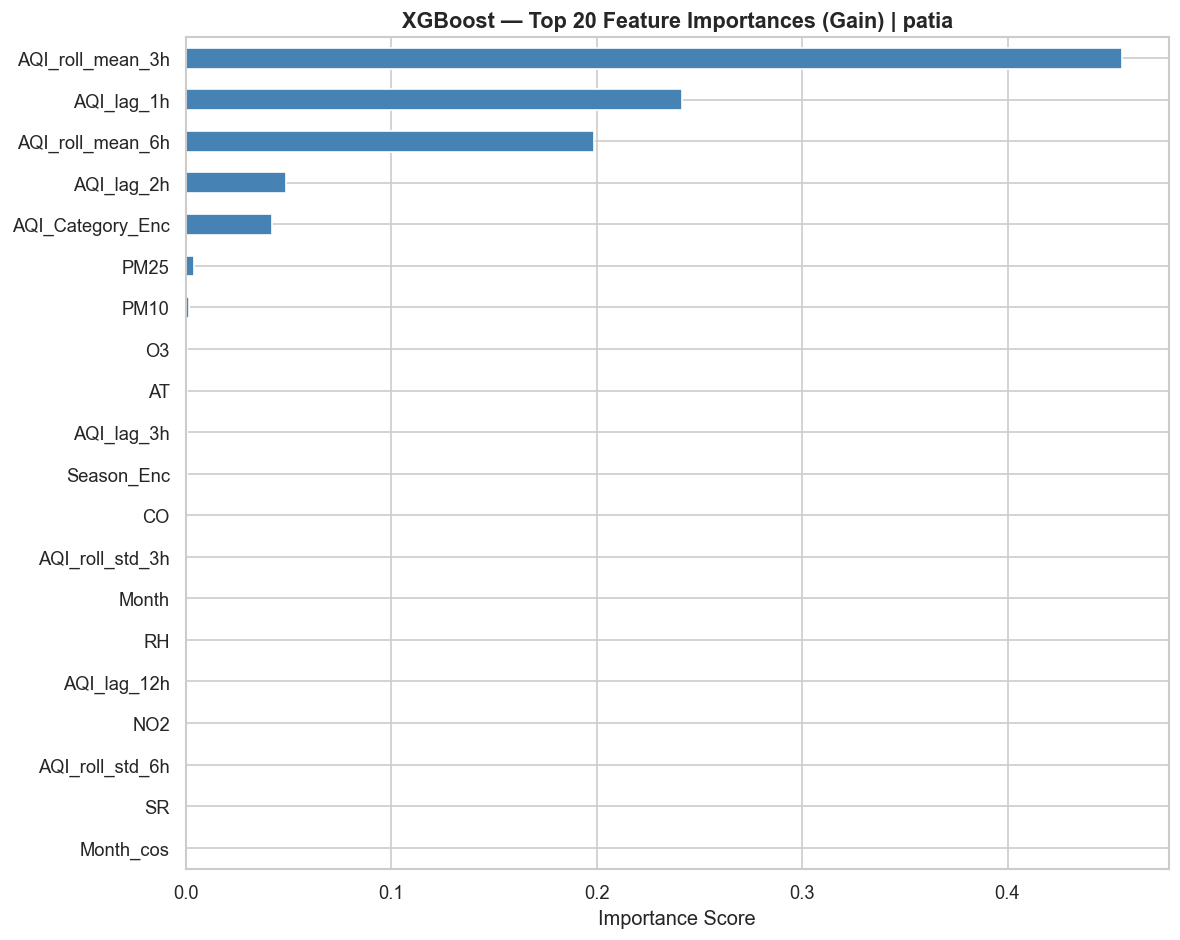

Top 10 features:
AQI_roll_mean_3h    0.455711
AQI_lag_1h          0.241628
AQI_roll_mean_6h    0.198492
AQI_lag_2h          0.048754
AQI_Category_Enc    0.042242
PM25                0.003910
PM10                0.001448
O3                  0.000710
AT                  0.000635
AQI_lag_3h          0.000581


In [30]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('XGBoost — Top 20 Feature Importances (Gain) | patia', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_feature_importance_patia.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(importance.head(10).to_string())


## 7. Learning Curve (Validation RMSE by Iteration)

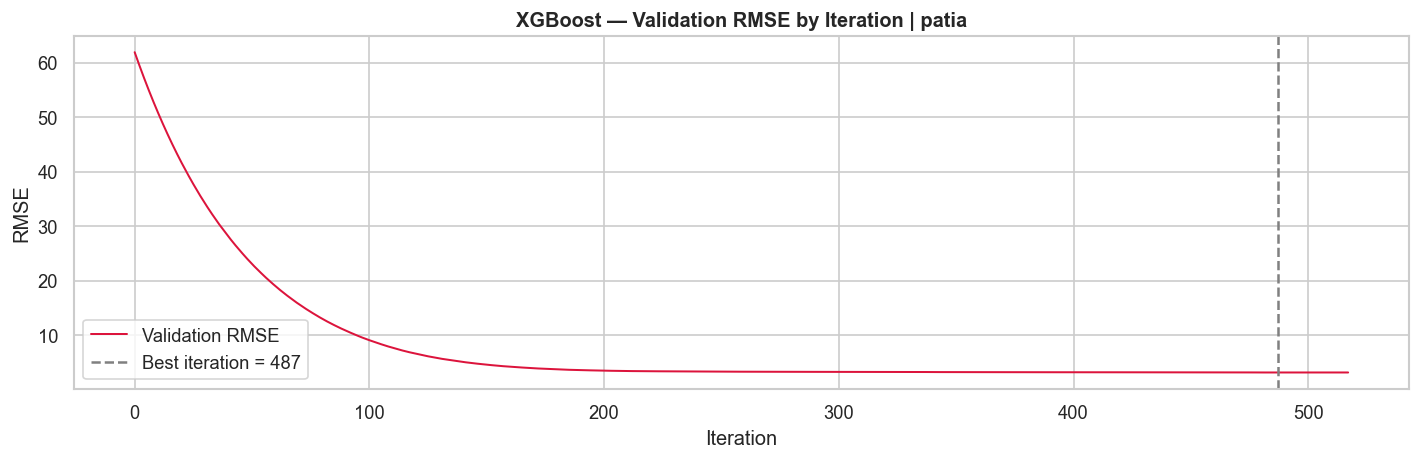

In [31]:
evals_result = model.evals_result()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(evals_result['validation_0']['rmse'], color='crimson', lw=1.2, label='Validation RMSE')
ax.axvline(model.best_iteration, linestyle='--', color='gray',
           label=f'Best iteration = {model.best_iteration}')
ax.set_title('XGBoost — Validation RMSE by Iteration | patia', fontsize=12, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_learning_curve_patia.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts to discrete AQI categories (Indian standard) to evaluate  
Accuracy, Precision, Recall, and F1 — both direct and recursive forecasts.


In [32]:
def categorize_aqi(aqi_values):
    """Map continuous AQI to Indian standard categories."""
    categories = []
    for val in aqi_values:
        if val <= 50:
            categories.append('Good')
        elif val <= 100:
            categories.append('Satisfactory')
        elif val <= 200:
            categories.append('Moderate')
        elif val <= 300:
            categories.append('Poor')
        elif val <= 400:
            categories.append('Very Poor')
        else:
            categories.append('Severe')
    return np.array(categories)


y_true_cont      = np.array(y_test.values).flatten()
pred_direct_cont = np.array(pred_direct).flatten()
pred_recur_cont  = np.array(pred_recursive).flatten()

y_true_class  = categorize_aqi(y_true_cont)
y_pred_direct = categorize_aqi(pred_direct_cont)
y_pred_recur  = categorize_aqi(pred_recur_cont)

labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
present_labels = [l for l in labels if l in y_true_class or l in y_pred_direct]

for name, y_pred_cls in [('Direct', y_pred_direct), ('Recursive', y_pred_recur)]:
    acc  = accuracy_score(y_true_class, y_pred_cls)
    prec = precision_score(y_true_class, y_pred_cls, average='weighted', zero_division=0)
    rec  = recall_score(y_true_class, y_pred_cls, average='weighted', zero_division=0)
    print(f'── {name} Forecast ──────────────────────────────')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f} (weighted)')
    print(f'  Recall    : {rec:.4f} (weighted)')
    print()

print('Classification Report (Direct Forecast):')
print(classification_report(y_true_class, y_pred_direct, labels=present_labels, zero_division=0))


── Direct Forecast ──────────────────────────────
  Accuracy  : 0.9986
  Precision : 0.9986 (weighted)
  Recall    : 0.9986 (weighted)

── Recursive Forecast ──────────────────────────────
  Accuracy  : 0.9990
  Precision : 0.9990 (weighted)
  Recall    : 0.9990 (weighted)

Classification Report (Direct Forecast):
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       698
Satisfactory       1.00      1.00      1.00       495
    Moderate       1.00      1.00      1.00       678
        Poor       1.00      1.00      1.00       860
   Very Poor       1.00      0.98      0.99       128

    accuracy                           1.00      2859
   macro avg       1.00      0.99      1.00      2859
weighted avg       1.00      1.00      1.00      2859



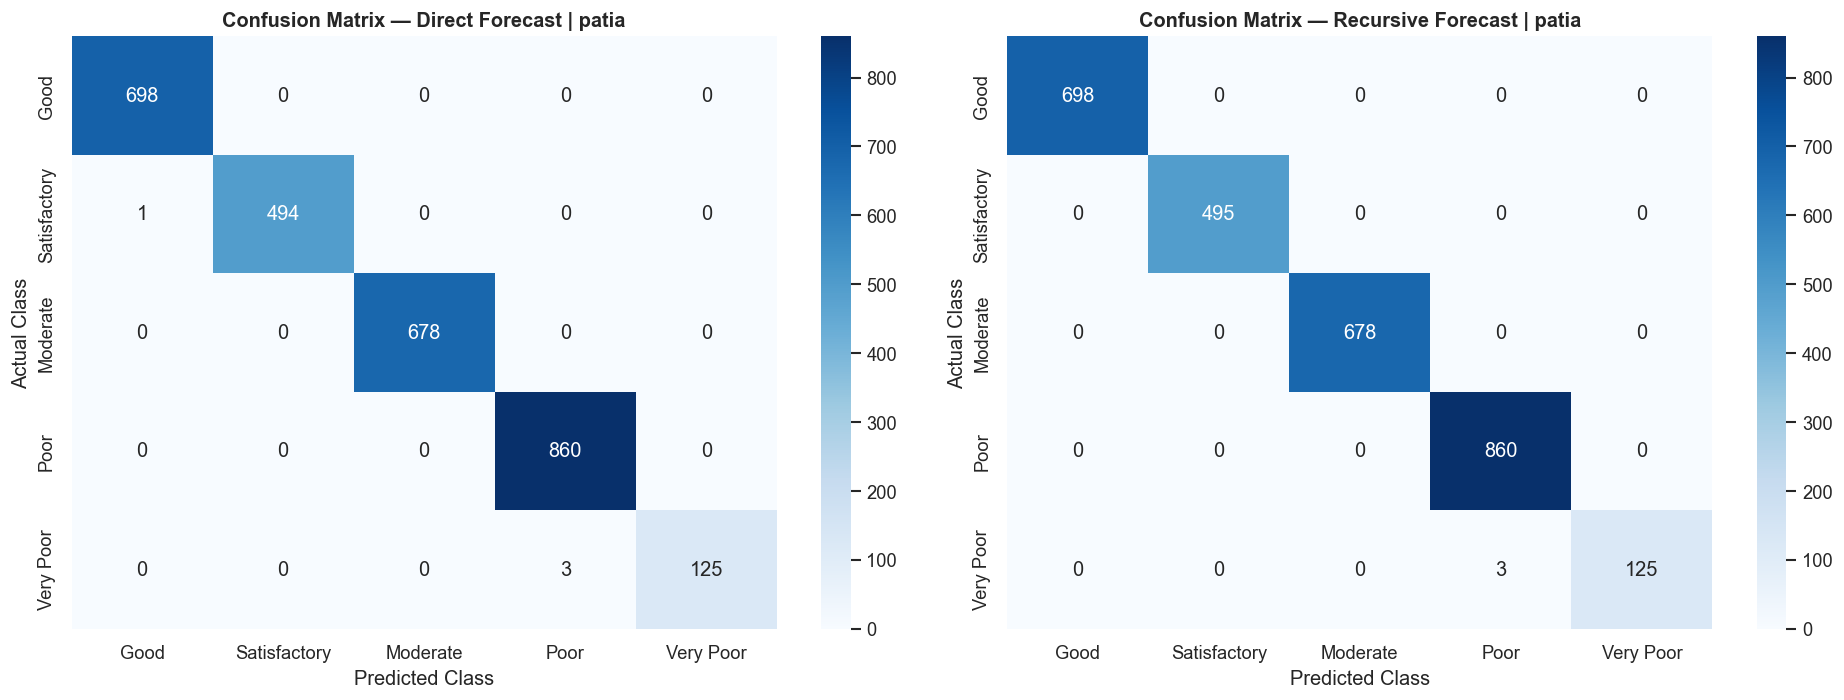

In [33]:
# ── Confusion matrix — direct forecast ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred_cls) in zip(axes, [('Direct', y_pred_direct), ('Recursive', y_pred_recur)]):
    cm = confusion_matrix(y_true_class, y_pred_cls, labels=present_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_labels, yticklabels=present_labels, ax=ax)
    ax.set_title(f'Confusion Matrix — {name} Forecast | patia', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('Actual Class')

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_confusion_matrix_patia.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Residual Analysis
Checking for systematic bias, heteroscedasticity, or seasonal residual patterns.


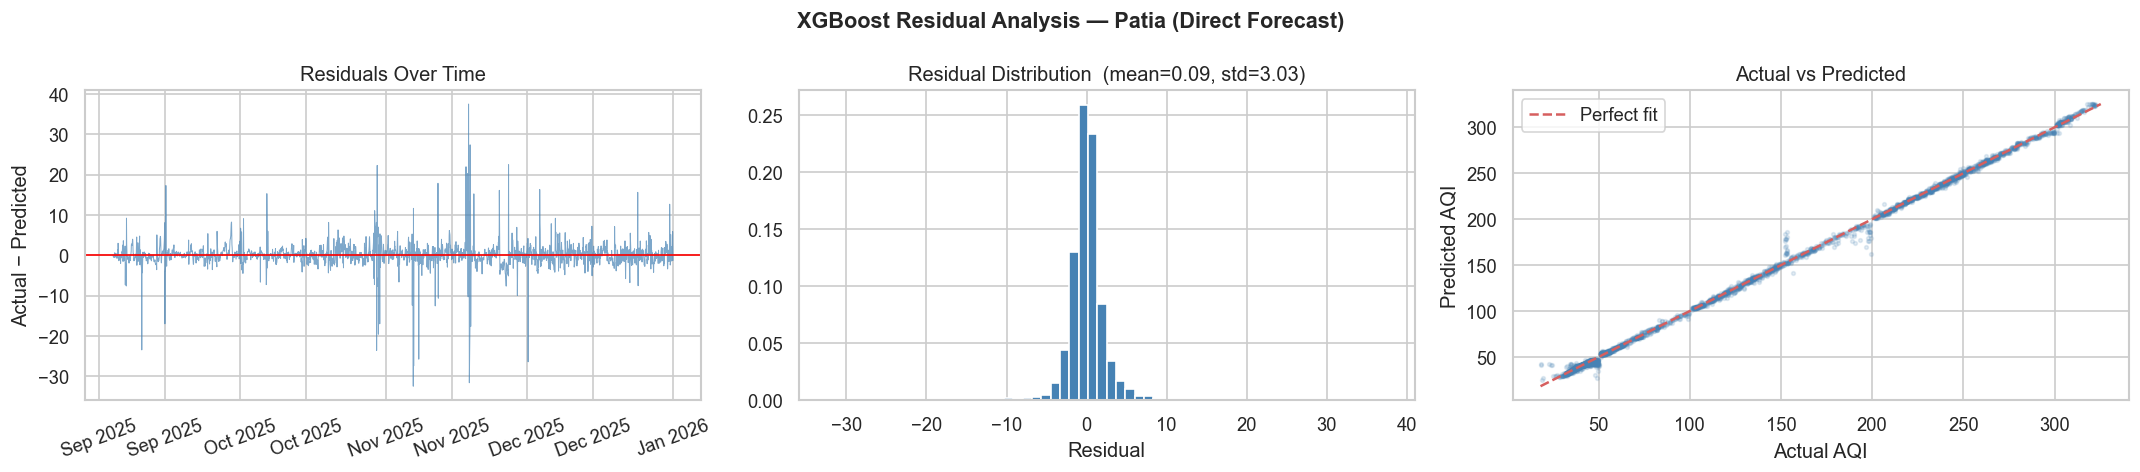

In [34]:
residuals = y_test.values - pred_direct

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Residuals over time
axes[0].plot(test['Timestamp'].values, residuals, color='steelblue', lw=0.6, alpha=0.7)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Actual − Predicted')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20)

# Residual distribution
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', density=True)
axes[1].set_title(f'Residual Distribution  (mean={residuals.mean():.2f}, std={residuals.std():.2f})')
axes[1].set_xlabel('Residual')

# Actual vs Predicted scatter
axes[2].scatter(y_test, pred_direct, alpha=0.15, s=5, color='steelblue')
lims = [min(y_test.min(), pred_direct.min()), max(y_test.max(), pred_direct.max())]
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual AQI')
axes[2].set_ylabel('Predicted AQI')
axes[2].legend()

plt.suptitle('XGBoost Residual Analysis — Patia (Direct Forecast)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_residual_analysis_patia.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Metrics Summary

In [35]:
summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
    'Direct Forecast': [round(rmse, 2), round(mae, 2), round(mape, 2)],
    'Recursive Forecast': [round(rmse_r, 2), round(mae_r, 2), round(mape_r, 2)],
})
print(summary.to_string(index=False))


  Metric  Direct Forecast  Recursive Forecast
    RMSE             3.03                3.88
     MAE             1.59                2.31
MAPE (%)             1.85                2.84


## 11. Save Model

In [36]:
import joblib

model_path = f'{MODEL_DIR}/patia_xgboost_aqi.pkl'
joblib.dump(model, model_path)
print(f'✅ Model saved to: {model_path}')
print(f'   Best iteration : {model.best_iteration}')
print(f'   Features used  : {len(feature_cols)}')


✅ Model saved to: saved_models/patia_xgboost_aqi.pkl
   Best iteration : 487
   Features used  : 48
